Nome: Felipe Marinho de Figueiredo
RA: 185607

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import math
import pandas as pd
from IPython.display import Image, display


**Parâmetros globais**

In [20]:
# Parâmetros globais: alterar aqui muda o notebook inteiro
TOL_PADRAO = 1e-6        # tolerância exigida no enunciado
MAX_ITER_PADRAO = 100    # limite de iterações exigido no enunciado
EPS_DIV = 1e-12          # |derivada| ou |denominador| abaixo disso é tratado como "zero"


**Funções e derivadas**

In [21]:
def f1(x):
  return x**2 - 2

def f2(x) :
  return x**3 - x -2

def f3(x) :
  return np.exp(-x) - x

def f4(x) :
  return x**3 - 2*x + 2

#Derivadas para o método de Newton
def df1(x):
  return 2*x

def df2(x):
  return 3*x**2 - 1

def df3(x):
  return -np.exp(-x)-1

def df4(x):
  return 3*x**2-2


## 2. Critério de parada e convenções adotadas

**Critério.** Os três métodos usam o mesmo critério, os **dois juntos**:

$$|x_{k+1}-x_k| < tol \quad \text{e} \quad |f(x_{k+1})| < tol, \qquad tol = 10^{-6}$$

**Por que os dois juntos.** Cada um sozinho pode enganar:
- só $|x_{k+1}-x_k|$: um passo pequeno não garante estar perto da raiz (o método pode estar andando devagar ou estagnado);
- só $|f(x_{k+1})|$: um resíduo pequeno não garante $x$ perto da raiz quando $f$ é muito plana ao redor dela; e, ao contrário, quando $f$ é muito íngreme, o $x$ pode estar ótimo e o resíduo ainda ser grande.

**Bisseção.** Usa o mesmo critério. Como $m_k$ é o ponto médio de uma das metades do intervalo anterior, $m_{k-1}$ é um *extremo* do intervalo atual $[a,b]$, logo

$$|m_k - m_{k-1}| = \frac{b-a}{2}.$$

Por isso o código usa `(b - a)/2` no lugar da diferença entre aproximações: é a mesma quantidade, também vale na 1ª iteração (que não tem $m_{k-1}$) e é a garantia de erro da bisseção. Como o resíduo também precisa ser menor que `tol`, alguns casos rodam 1 ou 2 iterações a mais que os 20 previstos por $(b-a)/2^k<10^{-6}$ (ver análise).

**Contagem de iterações.** Uma iteração é o cálculo de uma *nova* aproximação. Os chutes iniciais ($x_0$ no Newton; $x_0$ e $x_1$ na secante) **não contam**. Na bisseção não há chute inicial: cada ponto médio é uma aproximação nova, então $N$ pontos médios = $N$ iterações. Os GIFs seguem a mesma numeração (iteração 0 = chute inicial).

**Falhas detectadas** (o método devolve `convergiu = False` e um `motivo`):
- bisseção: `f(a)f(b) > 0`;
- Newton: `|f'(x_k)| < 1e-12`;
- secante: `|f(x_k) - f(x_{k-1})| < 1e-12`;
- qualquer método: `max_iter` (100) atingido sem convergir.

**Como alterar os parâmetros:** a tolerância, o limite de iterações e o limiar de "zero" ficam na célula de parâmetros globais; a função, os intervalos e os chutes ficam no dicionário `funcoes`.


**Estrutura de retorno (igual nos três métodos)**

In [22]:
def resultado(raiz, historico, iteracoes, convergiu, motivo, **extra):
    """Estrutura única devolvida pelos três métodos.

    raiz       : aproximação final (None se o método nem chegou a começar)
    historico  : lista de aproximações x_0, x_1, ... (na bisseção, os pontos médios)
    iteracoes  : quantas NOVAS aproximações o método calculou (chutes iniciais não contam)
    convergiu  : True ou False
    motivo     : "convergiu", "f(a)f(b) > 0", "f'(x) ~ 0", "denominador ~ 0", "max_iter atingido"
    extra      : informação específica de um método (ex.: intervalos da bisseção)
    """
    res = {
        "raiz": raiz,
        "historico": list(historico),
        "iteracoes": iteracoes,
        "convergiu": convergiu,
        "motivo": motivo,
    }
    res.update(extra)
    return res


**Método da bisseção**
O intervalo inicial é [a,b] que contenha a raiz e esse intervalo vai diminuindo. Além das aproximações, a função guarda o intervalo de cada passo (`intervalos`), que a animação reaproveita.

In [23]:
def bissecao(f, a, b, tol=TOL_PADRAO, max_iter=MAX_ITER_PADRAO):

    fa, fb = f(a), f(b)

    # Verificação inicial: sem mudança de sinal não há garantia de raiz em [a, b]
    if fa * fb > 0:
        return resultado(None, [], 0, False, "f(a)f(b) > 0", intervalos=[])

    # Caso trivial: um extremo já é raiz exata
    for ext, fext in ((a, fa), (b, fb)):
        if fext == 0:
            return resultado(ext, [ext], 0, True, "convergiu", intervalos=[(a, b)])

    historico = []
    intervalos = []      # intervalo [a, b] usado em cada iteração (para a animação)

    for i in range(1, max_iter + 1):

        m = (a + b) / 2
        fm = f(m)

        historico.append(m)
        intervalos.append((a, b))

        # Raiz exata: nada mais a fazer (e evita fa*fm = 0 bagunçar o intervalo)
        if fm == 0:
            return resultado(m, historico, i, True, "convergiu", intervalos=intervalos)

        # Critério de parada (os dois juntos, como em Newton e secante).
        # |x_k - x_(k-1)| = (b - a)/2 na bisseção (ver seção 2.2), então usamos (b - a)/2.
        passo = (b - a) / 2
        if passo < tol and abs(fm) < tol:
            return resultado(m, historico, i, True, "convergiu", intervalos=intervalos)

        # Intervalo novo
        if fa * fm < 0:
            b = m
        else:
            a = m
            fa = fm

    return resultado(historico[-1], historico, max_iter, False, "max_iter atingido",
                     intervalos=intervalos)


**Método de Newton**

In [24]:
def newton(f, df, x0, tol=TOL_PADRAO, max_iter=MAX_ITER_PADRAO):

    x = x0
    historico = [x0]

    for i in range(1, max_iter + 1):

        derivada = df(x)

        # Evita divisão por zero
        if abs(derivada) < EPS_DIV:
            return resultado(x, historico, i - 1, False, "f'(x) ~ 0")

        x_novo = x - f(x) / derivada
        historico.append(x_novo)

        # Critério de parada: passo pequeno E resíduo pequeno
        if abs(x_novo - x) < tol and abs(f(x_novo)) < tol:
            return resultado(x_novo, historico, i, True, "convergiu")

        x = x_novo

    return resultado(x, historico, max_iter, False, "max_iter atingido")


**Método da secante**

In [25]:
def secante(f, x0, x1, tol=TOL_PADRAO, max_iter=MAX_ITER_PADRAO):

    historico = [x0, x1]

    for i in range(1, max_iter + 1):

        denominador = f(x1) - f(x0)

        # Evita divisão por zero
        if abs(denominador) < EPS_DIV:
            return resultado(x1, historico, i - 1, False, "denominador ~ 0")

        x2 = x1 - f(x1) * (x1 - x0) / denominador
        historico.append(x2)

        # Critério de parada: passo pequeno E resíduo pequeno
        if abs(x2 - x1) < tol and abs(f(x2)) < tol:
            return resultado(x2, historico, i, True, "convergiu")

        x0, x1 = x1, x2

    return resultado(x1, historico, max_iter, False, "max_iter atingido")


**Valores iniciais**

In [26]:
funcoes = {
    "f1": {
        "f": f1,
        "df": df1,
        "intervalo": (1, 2),
        "newton": 1.5,
        "secante": (1, 2)
    },

    "f2": {
        "f": f2,
        "df": df2,
        "intervalo": (1, 2),
        "newton": 1.5,
        "secante": (1, 2)
    },

    "f3": {
        "f": f3,
        "df": df3,
        "intervalo": (0, 1),
        "newton": 0.5,
        "secante": (0, 1)
    },

    "f4": {
        "f": f4,
        "df": df4,
        "intervalo": (-2, -1),
        "newton": -2,
        "secante": (-2, -1)
    }
}


## 3. Tabela de resultados
Tolerância e limite de iterações vêm dos parâmetros globais.

In [27]:
def linha_da_tabela(nome_funcao, nome_metodo, valores_iniciais, f, res):
    """Transforma o resultado de qualquer método em uma linha da tabela."""
    raiz = res["raiz"]
    return {
        "Função": nome_funcao,
        "Método": nome_metodo,
        "Valores iniciais": valores_iniciais,
        "Raiz aproximada": raiz,
        "|f(x)| final": abs(f(raiz)) if raiz is not None else None,   # raiz None = método não começou
        "Iterações": res["iteracoes"],
        "Resultado": "Convergiu" if res["convergiu"] else f"Falhou: {res['motivo']}",
    }


def rodar_todos(nome, dados, tol=TOL_PADRAO, max_iter=MAX_ITER_PADRAO):
    """Roda os três métodos numa função e devolve as três linhas da tabela."""
    f, df = dados["f"], dados["df"]
    a, b = dados["intervalo"]
    x0 = dados["newton"]
    s0, s1 = dados["secante"]
    return [
        linha_da_tabela(nome, "Bisseção", f"[{a}, {b}]", f, bissecao(f, a, b, tol, max_iter)),
        linha_da_tabela(nome, "Newton",   f"x0 = {x0}",  f, newton(f, df, x0, tol, max_iter)),
        linha_da_tabela(nome, "Secante",  f"({s0}, {s1})", f, secante(f, s0, s1, tol, max_iter)),
    ]


In [28]:
linhas = []
for nome, dados in funcoes.items():
    linhas += rodar_todos(nome, dados)      # usa TOL_PADRAO e MAX_ITER_PADRAO

tabela = pd.DataFrame(linhas)
tabela.style.format({"Raiz aproximada": "{:.8f}", "|f(x)| final": "{:.2e}"}, na_rep="—")


,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações,Resultado
0,f1,Bisseção,"[1, 2]",1.41421366,2.69e-07,21,Convergiu
1,f1,Newton,x0 = 1.5,1.41421356,4.44e-16,4,Convergiu
2,f1,Secante,"(1, 2)",1.41421356,8.88e-16,6,Convergiu
3,f2,Bisseção,"[1, 2]",1.52137971,1.45e-08,22,Convergiu
4,f2,Newton,x0 = 1.5,1.52137971,4.53e-14,3,Convergiu
5,f2,Secante,"(1, 2)",1.52137971,1.84e-14,7,Convergiu
6,f3,Bisseção,"[0, 1]",0.56714344,2.35e-07,20,Convergiu
7,f3,Newton,x0 = 0.5,0.56714329,4.44e-15,3,Convergiu
8,f3,Secante,"(0, 1)",0.56714329,1.24e-13,5,Convergiu
9,f4,Bisseção,"[-2, -1]",-1.76929235,2.55e-09,21,Convergiu


## 4. Testes dos casos de falha
Cada linha provoca de propósito uma das detecções exigidas no enunciado: `f(a)f(b) > 0`, derivada ≈ 0, denominador ≈ 0 e ausência de convergência em `max_iter`.

In [29]:
# Cada linha provoca de propósito uma das falhas que o enunciado manda detectar.
testes_falha = [
    # (descrição,                               resultado do método)
    ("Bisseção f4 em [0, 1]  (f(0)=2, f(1)=1: mesmo sinal)",   bissecao(f4, 0, 1)),
    ("Newton f1 com x0 = 0  (f'(0) = 0)",                       newton(f1, df1, 0)),
    ("Newton f4 com x0 = sqrt(2/3)  (f' = 0 no chute)",         newton(f4, df4, math.sqrt(2/3))),
    ("Secante f1 com (-1, 1)  (f(-1) = f(1): denominador 0)",   secante(f1, -1, 1)),
    ("Newton f4 com x0 = 0  (ciclo 0 -> 1 -> 0)",               newton(f4, df4, 0)),
    ("Bisseção f1 em [1, 2] com max_iter = 5",                  bissecao(f1, 1, 2, max_iter=5)),
]

tabela_falhas = pd.DataFrame([
    {
        "Teste": desc,
        "Convergiu": res["convergiu"],
        "Motivo": res["motivo"],
        "Iterações": res["iteracoes"],
        "Primeiras aproximações": [round(x, 4) for x in res["historico"][:5]],
    }
    for desc, res in testes_falha
])
tabela_falhas


,Teste,Convergiu,Motivo,Iterações,Primeiras aproximações
0,"Bisseção f4 em [0, 1] (f(0)=2, f(1)=1: mesmo ...",False,f(a)f(b) > 0,0,[]
1,Newton f1 com x0 = 0 (f'(0) = 0),False,f'(x) ~ 0,0,[0]
2,Newton f4 com x0 = sqrt(2/3) (f' = 0 no chute),False,f'(x) ~ 0,0,[0.8165]
3,"Secante f1 com (-1, 1) (f(-1) = f(1): denomin...",False,denominador ~ 0,0,"[-1, 1]"
4,Newton f4 com x0 = 0 (ciclo 0 -> 1 -> 0),False,max_iter atingido,100,"[0, 1.0, 0.0, 1.0, 0.0]"
5,"Bisseção f1 em [1, 2] com max_iter = 5",False,max_iter atingido,5,"[1.5, 1.25, 1.375, 1.4375, 1.4062]"


**Casos extras (justificativa):** em $f_4$ o Newton com $x_0=-2$ converge, mas a análise da dependência do chute inicial exige testar outros valores. Escolhi chutes dos dois lados da raiz ($-1$, $-0{,}5$, $0{,}5$, $2$) e os pontos $0$ e $1$, que formam o ciclo de Newton, comparando com a secante.

In [30]:
# Casos extras para estudar a dependência do chute inicial em f4 (a única raiz real é ~ -1,7693)
extras = []
for x0 in [-2, -1, -0.5, 0, 0.5, 1, 2]:
    extras.append(linha_da_tabela("f4", "Newton", f"x0 = {x0}", f4, newton(f4, df4, x0)))

for s0, s1 in [(0, 1), (0.5, 1), (1, 2)]:
    extras.append(linha_da_tabela("f4", "Secante", f"({s0}, {s1})", f4, secante(f4, s0, s1)))

tabela_extras = pd.DataFrame(extras)
tabela_extras.style.format({"Raiz aproximada": "{:.8f}", "|f(x)| final": "{:.2e}"}, na_rep="—")


,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações,Resultado
0,f4,Newton,x0 = -2,-1.76929235,5.05e-13,4,Convergiu
1,f4,Newton,x0 = -1,-1.76929235,0.00e+00,8,Convergiu
2,f4,Newton,x0 = -0.5,1.00000000,1.00e+00,100,Falhou: max_iter atingido
3,f4,Newton,x0 = 0,0.00000000,2.00e+00,100,Falhou: max_iter atingido
4,f4,Newton,x0 = 0.5,-1.76929235,0.00e+00,9,Convergiu
5,f4,Newton,x0 = 1,1.00000000,1.00e+00,100,Falhou: max_iter atingido
6,f4,Newton,x0 = 2,-1.76929235,0.00e+00,9,Convergiu
7,f4,Secante,"(0, 1)",-1.76929235,8.49e-13,25,Convergiu
8,f4,Secante,"(0.5, 1)",-1.76929235,3.68e-13,45,Convergiu
9,f4,Secante,"(1, 2)",-1.76929235,8.49e-13,24,Convergiu


## Animações
O `criar_gif` cuida da mecânica (curva, eixo, título com iteração, $x$ e $|f(x)|$). Cada método tem só a função que desenha a geometria do quadro: intervalo $[a,b]$ na bisseção, tangente até o eixo no Newton e reta secante até o eixo na secante. Todos usam os resultados dos mesmos métodos da tabela.

In [31]:
def janela_x(pontos, margem_min=0.5, fator=0.25):
    """Janela horizontal que contém todos os pontos, com folga."""
    lo, hi = min(pontos), max(pontos)
    m = max(margem_min, fator * (hi - lo))
    return lo - m, hi + m


def criar_gif(f, quadros, xmin, xmax, titulo, arquivo, desenhar_passo, fps=2):
    """Gera o GIF. Só a mecânica; a geometria de cada método vem de desenhar_passo.

    quadros        : lista de (iteracao, x_atual), um elemento por quadro
    desenhar_passo : função(ax, j) que desenha a geometria do quadro j
    """
    xs = np.linspace(xmin, xmax, 500)
    ys = f(xs)
    ymin, ymax = min(ys.min(), 0), max(ys.max(), 0)      # o eixo y = 0 tem que aparecer sempre
    folga = 0.15 * (ymax - ymin)
    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    def atualizar(j):
        ax.clear()                                       # cada quadro começa do zero
        ax.plot(xs, ys, lw=2, label="f(x)")
        ax.axhline(0, color="black", lw=0.8)             # eixo y = 0
        desenhar_passo(ax, j)
        it, xk = quadros[j]
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin - folga, ymax + folga)
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=8)
        ax.set_title(f"{titulo}\nIteração {it} | x = {xk:.8f} | |f(x)| = {abs(f(xk)):.2e}")

    fig.subplots_adjust(bottom=0.27, top=0.87)
    anim = FuncAnimation(fig, atualizar, frames=len(quadros), interval=1000 / fps)
    anim.save(arquivo, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"GIF salvo em {arquivo}  ({len(quadros)} quadros)")


**Animação da bisseção**

In [32]:
def gif_bissecao(f, a, b, arquivo, titulo="Bisseção", **kw):
    res = bissecao(f, a, b, **kw)                    # a MESMA função da tabela
    hist, ints = res["historico"], res["intervalos"]
    quadros = [(k + 1, x) for k, x in enumerate(hist)]   # iteração 1 = primeiro ponto médio

    def desenhar(ax, j):
        a_j, b_j = ints[j]
        ax.axvspan(a_j, b_j, color="orange", alpha=0.2, label="intervalo [a, b]")
        for ext in (a_j, b_j):
            ax.vlines(ext, 0, f(ext), colors="orange", linestyles="--")
        ax.plot(hist[:j], f(np.array(hist[:j])), "o", color="gray", ms=4, label="aprox. anteriores")
        ax.plot(hist[j], f(hist[j]), "ro", label="aproximação atual")

    xmin, xmax = janela_x([a, b])
    criar_gif(f, quadros, xmin, xmax, titulo, arquivo, desenhar)
    return res


**Animação de Newton**

In [33]:
def gif_newton(f, df, x0, arquivo, titulo="Newton", **kw):
    res = newton(f, df, x0, **kw)
    hist = res["historico"]
    quadros = [(k, x) for k, x in enumerate(hist)]       # iteração 0 = chute inicial

    def desenhar(ax, j):
        ax.plot(hist[:j], f(np.array(hist[:j])), "o", color="gray", ms=4, label="aprox. anteriores")
        if j >= 1:
            xp, xn = hist[j - 1], hist[j]
            ax.vlines(xp, 0, f(xp), colors="gray", linestyles=":")
            # tangente em x_(j-1): vai do ponto da curva até o eixo, onde nasce x_j
            ax.plot([xp, xn], [f(xp), 0], "--", color="tab:green", label="tangente em x_(k-1)")
            ax.plot(xn, 0, "s", color="tab:green", ms=5)
        ax.plot(hist[j], f(hist[j]), "ro", label="aproximação atual")

    # janela baseada nos primeiros passos (os maiores); depois disso o método já está "em cima" da raiz
    xmin, xmax = janela_x(hist[:3], margem_min=0.02, fator=0.5)
    criar_gif(f, quadros, xmin, xmax, titulo, arquivo, desenhar)
    return res


**Animação da secante**

In [34]:
def gif_secante(f, x0, x1, arquivo, titulo="Secante", **kw):
    res = secante(f, x0, x1, **kw)
    hist = res["historico"]                              # x0, x1, x2, ...
    # quadro 0 = chutes iniciais (iteração 0); quadro j>=1: reta por x_(j-1) e x_j que gera x_(j+1)
    quadros = [(j, hist[j + 1]) for j in range(len(hist) - 1)]

    def desenhar(ax, j):
        ax.plot(hist[:j + 1], f(np.array(hist[:j + 1])), "o", color="gray", ms=4,
                label="aprox. anteriores")
        if j >= 1:
            xa, xb, xc = hist[j - 1], hist[j], hist[j + 1]
            m = (f(xb) - f(xa)) / (xb - xa)              # coeficiente angular da reta secante
            xl = np.array([min(xa, xb, xc), max(xa, xb, xc)])
            ax.plot(xl, f(xb) + m * (xl - xb), "--", color="tab:green", label="reta secante")
            ax.plot(xc, 0, "s", color="tab:green", ms=5)  # onde a reta cruza o eixo = nova aprox.
        ax.plot(hist[j + 1], f(hist[j + 1]), "ro", label="aproximação atual")

    xmin, xmax = janela_x(hist[:4], margem_min=0.02, fator=0.5)
    criar_gif(f, quadros, xmin, xmax, titulo, arquivo, desenhar)
    return res


**Gerando GIFs**

GIF salvo em bissecao_f1.gif  (21 quadros)


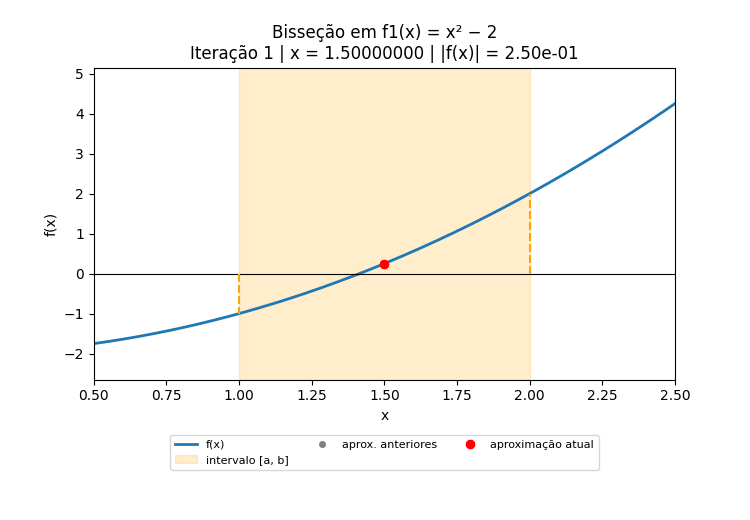

GIF salvo em newton_f2.gif  (4 quadros)


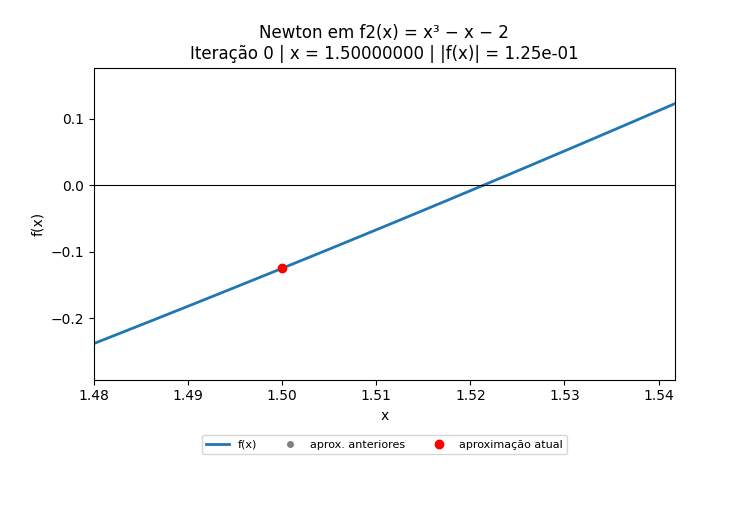

GIF salvo em secante_f3.gif  (6 quadros)


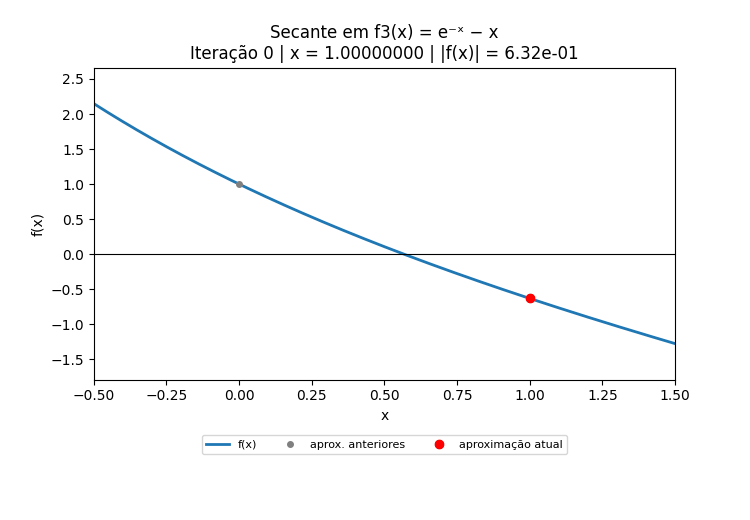

GIF salvo em newton_f4_ciclo.gif  (9 quadros)


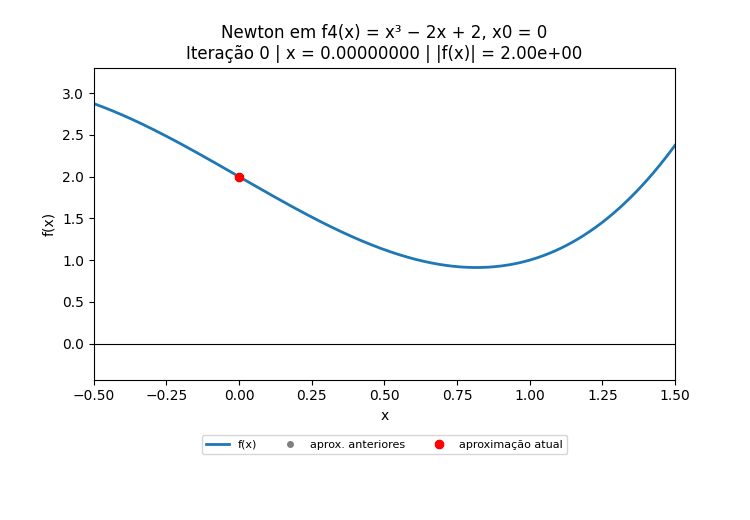

In [35]:
#GIF 1 - bisseção em f1
gif_bissecao(f1, 1, 2, "bissecao_f1.gif", "Bisseção em f1(x) = x² − 2")
display(Image(filename="bissecao_f1.gif"))

#GIF 2 - Newton em f2
gif_newton(f2, df2, 1.5, "newton_f2.gif", "Newton em f2(x) = x³ − x − 2")
display(Image(filename="newton_f2.gif"))

#GIF 3 - secante em f3
gif_secante(f3, 0, 1, "secante_f3.gif", "Secante em f3(x) = e⁻ˣ − x")
display(Image(filename="secante_f3.gif"))

#GIF 4 (extra) - Newton preso no ciclo 0 -> 1 -> 0 em f4 (só 8 iterações para o GIF não ficar enorme)
gif_newton(f4, df4, 0, "newton_f4_ciclo.gif", "Newton em f4(x) = x³ − 2x + 2, x0 = 0", max_iter=8)
display(Image(filename="newton_f4_ciclo.gif"))


In [36]:
arquivos_gif = ["bissecao_f1.gif", "newton_f2.gif", "secante_f3.gif", "newton_f4_ciclo.gif"]
try:
    from google.colab import files
    for arq in arquivos_gif:
        files.download(arq)
except ImportError:
    print("Fora do Colab: os GIFs estão salvos na pasta do notebook:", arquivos_gif)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Análise dos resultados

**Valores sugeridos (tabela principal).** Todos os métodos convergiram, para $f_1$: $\sqrt 2 \approx 1{,}41421356$; $f_2$: $\approx 1{,}52137971$; $f_3$: $\approx 0{,}56714329$; $f_4$: $\approx -1{,}76929235$. Em todas as linhas $|f(x)|$ final ficou abaixo de $10^{-6}$, como o critério exige.

- **Bisseção:** 20 a 22 iterações, sempre a mais lenta. O erro cai só pela metade a cada passo (convergência linear): $(b-a)/2^k < 10^{-6}$ dá $k = 20$ para intervalos de largura 1. Em $f_1$, $f_2$ e $f_4$ foram necessárias 21 ou 22 iterações porque, na 20ª, a largura do intervalo já era suficiente mas o resíduo ainda não era menor que $10^{-6}$ (em $f_1$ valia $1{,}6\times10^{-6}$). Isso mostra por que o critério isolado da largura poderia declarar convergência com resíduo acima da tolerância. Em compensação, é o único método que **sempre converge** quando $f(a)f(b)<0$ e $f$ é contínua.
- **Newton:** 3 a 4 iterações, o mais rápido. A convergência é quadrática: perto da raiz, o número de casas corretas praticamente dobra a cada passo. O custo é precisar de $f'$ e depender do chute inicial.
- **Secante:** 5 a 7 iterações, entre os dois. Não precisa de derivada (ordem $\approx 1{,}618$), mas também não tem garantia de convergência.

**Dependência do chute inicial (casos extras em $f_4$).**
- **Newton falhou em 3 dos 7 chutes testados** ($x_0=-0{,}5$, $0$ e $1$): as iterações ficam presas em ciclos (0 → 1 → 0 → ...) e o método atinge `max_iter`. Com $x_0=-1$ o primeiro passo joga o método para $-4$ (a tangente é quase horizontal), e ele ainda converge, em 8 iterações; com $x_0 = 0{,}5$ e $2$ convergem em 9. Ou seja, chutes visivelmente "próximos" da raiz não garantem nada.
- **Em $x_0=\sqrt{2/3}$**, onde $f_4'=0$, o Newton nem dá o primeiro passo (`f'(x) ~ 0`), conforme os testes de falha da seção 4.
- **A secante convergiu nos 3 casos extras** (chutes $(0,1)$, $(0{,}5,1)$ e $(1,2)$), mas gastou 24 a 45 iterações: ela escapa do ciclo que prende o Newton, porém vagueia bastante antes de "achar" a raiz.

**Conclusão.** A bisseção é robusta e lenta, exige um intervalo com mudança de sinal e tem erro garantido. Newton é o mais rápido, mas sensível ao chute inicial e precisa de $f'$. A secante é um meio-termo: sem derivada, quase tão rápida quanto Newton quando o chute é bom, mas sem garantia. Na prática, é comum usar a bisseção para localizar a raiz e depois refinar com Newton ou secante.
